In [1]:
import sys, os
sys.path.append(os.path.abspath('../..'))
from status_fields.status_fields_config_oct3v1_brws_250525 import STATUS_FIELDS_CONFIG
from utlis.scan_engine_utlis.scan_eng_big_utlis import log_folder_to_parquet_sep
from utlis.scan_engine_utlis.scan_engine_utlis import read_all_parquet_files

base_folder = "/data/big_rim/rsync_dcc_sum/Oct3V1" #"/data/big_rim/rsync_dcc_sum/24summ" #"/data/big_rim/rsync_dcc_sum/25Apri_social" #"/data/big_rim/rsync_dcc_sum/Oct3V1" #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Replace with your base folder
# save_path = os.path.join(base_folder, 'paret')
failed_paths_file = '/data/big_rim/rsync_dcc_sum/Oct3V1/sync_failed_brws.txt'  # File containing failed paths


force_rescan_rec_files = [
    # ('2023-10-01', '001'),
    # ('2023-10-02', '002'),
    # Add more as needed
]
rescan_threshold_days = 0.0001 # 7 days, but guess if i mess up i can just change it to automatically rescan all, smile... #0.1

log_folder_to_parquet_sep(base_folder, failed_paths_file, STATUS_FIELDS_CONFIG,
                            force_rescan_rec_files=force_rescan_rec_files,
                            rescan_threshold_days=rescan_threshold_days)


all_df = read_all_parquet_files(base_folder)

Log for #calib_before saved at /data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_03_micecolor_test/#calib_before/folder_log.parquet
Log for 24Anshu_f_paint_2mice_2 saved at /data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_03_micecolor_test/24Anshu_f_paint_2mice_2/folder_log.parquet
Log for #Anshu_f_bleach_2mice saved at /data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_03_micecolor_test/#Anshu_f_bleach_2mice/folder_log.parquet
Log for 24Anshu_f_paint_2mice saved at /data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_03_micecolor_test/24Anshu_f_paint_2mice/folder_log.parquet
Log for 24Anshu_f_bleach_2mice saved at /data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_03_micecolor_test/24Anshu_f_bleach_2mice/folder_log.parquet
Log for trashmini_240916v1r1_miceleash_test_19_15 saved at /data/big_rim/rsync_dcc_sum/Oct3V1/2025_01_23/trashmini_240916v1r1_miceleash_test_19_15/folder_log.parquet
Log for 2social_mini_0605pmc_single_15_38 saved at /data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_30/2social_mini_0605pmc_single_15_38/folder_l

In [2]:
import pyarrow.compute as pc
from functools import reduce


table = all_df #combined_df
# Filter mir_generate_param == 0 and sync != 3
conditions = [
   # pc.equal(table['mir_generate_param'], '0'),
   # pc.equal(table['sync'], '1'),
   # pc.not_equal(table['sync'], '3'),
   # pc.equal(table['com'], '1'),
   # # pc.equal(table['com_vis'], '1'),
   # # pc.equal(table['v1'], '1'),
   # pc.equal(table['dannce'], '1'),
   #  
   # pc.equal(table['test'], '1'),
   # pc.equal(table['dannce_vis'], '1'),
   pc.equal(table['social'], '1'),  
   pc.equal(table['mini_6cam_map'], '1'),
   # pc.equal(table['date_folder'], '2025_05_16'),
   pc.equal(table['mini_rec_sync_com'], '1'),
   # pc.equal(table['mini_rec_sync'], '1'),
   #mini_rec_sync mini_rec_sync_com
   # mini_6cam_map
]

filter_mask = reduce(pc.and_, conditions)


# Apply the filter and print the results
filtered_table = table.filter(filter_mask)

# Print each row of the filtered table
print(filtered_table.to_pandas())  # This will display the filtered data in a familiar pandas-like format


   mir_generate_param sync mini_6cam_map dropf_handle com com_vis social  \
0                   1    1             1            0   1       1      1   
1                   1    1             1            0   1       1      1   
2                   1    1             1            0   1       1      1   
3                   1    1             1            0   1       1      1   
4                   1    1             1            0   1       1      1   
5                   1    1             1            0   1       1      1   
6                   1    1             1            0   1       1      1   
7                   1    1             1            0   1       1      1   
8                   1    1             1            0   1       1      1   
9                   1    1             1            0   1       1      1   
10                  1    1             1            0   1       1      1   

   miniscope test after_oxytocin before_oxytocin dannce dannce_vis  \
0          1    1

In [3]:
# Convert and flatten the ChunkedArray
rec_paths = filtered_table["rec_path"].to_pylist()

rec_paths

['/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_02_27/20241015PMCBE1mini_p20241015PMCRE1_12_33',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_03_11/20241224PMCLE1mini_p20240303PMC2_14_44',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_31/20240919v1l5r2mini_p20240717PMC_social_14_04',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2024_11_01/2social_mini_20240910V1r_AO_single_12_50',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2024_11_01/2social_mini_20240819V1r1_AO_single_14_30',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_31/2social_mini_20240819V1r1_single_11_29',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_05_16/20241216V1RE1Fmini_p20241216RE2',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_05_16/20241216V1RE1Fmini_p20241224PMCLE1',
 '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_05_16/20240303PMCBE0r1coatedmini_p20240303RE1']

# export

In [ ]:
from pathlib import Path
import pyarrow as pa
import pyarrow.csv as pacsv
import pyarrow.compute as pc
import re
import json
import os

PAIR_COLS = [
    "source_rec_path", "animal1_key", "animal2_key",
    "area1", "area2", "short_id1", "short_id2", 
    "session_manual", "include", "notes"
]

# Animal key aliases - add your own here!
# Alias -> canonical animal key
ALIASES = {
    # Example: "mouse1": "pmc_L",
    # Example: "lefty": "v1_left",
}


def load_registry():
    """Load animal IDs from file."""
    if os.path.exists("animal_ids.json"):
        with open("animal_ids.json") as f:
            return json.load(f)
    return {}

def save_registry(animal_dict):
    """Save animal IDs to file."""
    with open("animal_ids.json", 'w') as f:
        json.dump(animal_dict, f, indent=2)

def seed_pairs_csv(filtered_table: pa.Table, out_csv: str, prev_csv: str = None):
    """Create/append pairs CSV with paths from filtered_table."""
    t = filtered_table
    if "is_social" in t.schema.names:
        t = t.filter(pc.field("is_social") == True)
    
    paths = pc.unique(t["rec_path"])
    blanks = {c: pa.array([""] * len(paths), pa.string()) for c in PAIR_COLS[1:]}
    new_rows = pa.table({"source_rec_path": paths, **blanks})
    
    if prev_csv and Path(prev_csv).exists():
        prev = pacsv.read_csv(prev_csv)
        is_dup = pc.is_in(new_rows["source_rec_path"], prev["source_rec_path"])
        out = pa.concat_tables([prev, new_rows.filter(pc.invert(is_dup))], promote=True)
    else:
        out = new_rows
    
    pacsv.write_csv(out, out_csv)
    return out_csv


def autofill_short_ids(pairs_csv: str):
    """Auto-assign short IDs based on animal_key. Area inferred from key name."""
    rows = pacsv.read_csv(pairs_csv).to_pylist()
    
    # Track: animal_key -> (area, num)
    animal_to_id = load_registry()
    used_nums = {"MC": set(), "VC": set(), "UNK": set()}
    

    for animal, short_id in animal_to_id.items():
        area = short_id[:2]  # "MC1" -> "MC"
        num = int(short_id[2:])  # "MC1" -> 1
        used_nums[area].add(num)


    def resolve_alias(key: str) -> str:
        """Resolve alias to canonical animal key."""
        return ALIASES.get(key, key)
    
    def infer_area(key: str) -> str:
        """Guess area from animal key: v1/V1 -> VC, pmc -> MC, else UNK"""
        k = key.lower()
        if "v1" in k or k.startswith("v"):
            return "VC"
        if "pmc" in k or "mc" in k:
            return "MC"
        return "UNK"
    
    # First pass: collect existing IDs
    for r in rows:
        for animal_key, area_col, sid in [
            ("animal1_key", "area1", "short_id1"), 
            ("animal2_key", "area2", "short_id2")
        ]:
            key = resolve_alias(str(r.get(animal_key) or "").strip())
            if not key:
                continue
            
            # Parse existing short_id like "MC3", "VC12", or "UNK5"
            sid_val = str(r.get(sid) or "").strip().upper()
            m = re.match(r"^(MC|VC|UNK)(\d+)$", sid_val)
            if m:
                area, num = m.group(1), int(m.group(2))
                animal_to_id[key] = (area, num)
                used_nums[area].add(num)
    
    # Second pass: assign missing IDs
    for r in rows:
        for animal_key, area_col, sid in [
            ("animal1_key", "area1", "short_id1"), 
            ("animal2_key", "area2", "short_id2")
        ]:
            key = resolve_alias(str(r.get(animal_key) or "").strip())
            if not key:
                continue
            
            if key not in animal_to_id:
                area = infer_area(key)
                num = 1
                while num in used_nums[area]:
                    num += 1
                animal_to_id[key] = (area, num)
                used_nums[area].add(num)
            
            # Write back area and short_id
            area, num = animal_to_id[key]
            r[area_col] = area
            r[sid] = f"{area}{num}"
    
    # Save
    out_tab = pa.table({c: pa.array([r.get(c, "") for r in rows], pa.string()) for c in PAIR_COLS})
    pacsv.write_csv(out_tab, pairs_csv)
    save_registry(animal_to_id)
    
    return pairs_csv


def build_plan_from_pairs(pairs_csv: str, profile: dict) -> list[dict]:
    """Build export plan from pairs CSV."""
    rows = pacsv.read_csv(pairs_csv).to_pylist()
    
    # Filter: both animals filled, not excluded
    def _include(r):
        inc = str(r.get("include") or "").strip().lower()
        excluded = inc in {"0", "no", "n", "false", "skip", "exclude"}
        has_both = str(r.get("animal1_key") or "").strip() and str(r.get("animal2_key") or "").strip()
        return has_both and not excluded
    
    rows = [r for r in rows if _include(r)]
    if not rows:
        return []
    
    # Group by pair using short_id
    from collections import defaultdict
    groups = defaultdict(list)
    
    for r in rows:
        id1 = str(r.get("short_id1") or "").strip()
        id2 = str(r.get("short_id2") or "").strip()
        pair_key = f"{id1}+{id2}"  # KEEP ORDER - NO SORTING!
        groups[pair_key].append(r)
    
    # Build plan
    plan = []
    for pair_key, items in groups.items():
        items.sort(key=lambda r: r.get("source_rec_path", ""))
        for i, r in enumerate(items, 1):
            session = str(r.get("session_manual") or "").strip()
            sidx = int(session) if session and session.isdigit() else i
            
            plan.append({
                "dest_rel_path": f"social/{pair_key}_S{sidx}/",
                "source_rec_path": r.get("source_rec_path", ""),
                "id": pair_key,
                "session_index": sidx,
                "path_globs": profile.get("includes", []),
            })
    
    return plan

In [10]:
from export_profiles import load_profiles

profiles = load_profiles("profiles.yaml")
profile = profiles["default"]

In [6]:
# 1. Create CSV
seed_pairs_csv(filtered_table, "./social_pairs.csv", prev_csv="./social_pairs.csv")

# 2. Manually edit: fill in animal1_key, animal2_key (e.g., "pmc_L", "v1_R")

# 3. Auto-assign IDs
autofill_short_ids("./social_pairs.csv")  # Creates MC1, VC1, etc.

# 4. Build plan
plan = build_plan_from_pairs("./social_pairs.csv", profile)

/tmp/ipykernel_119304/4216451977.py:2: FutureWarning: promote has been superseded by promote_options='default'.
  seed_pairs_csv(filtered_table, "./social_pairs.csv", prev_csv="./social_pairs.csv")


In [7]:
plan

[{'dest_rel_path': 'social/VC1+MC1_S1/',
  'source_rec_path': '/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30',
  'id': 'VC1+MC1',
  'session_index': 1,
  'path_globs': ['videos/**',
   'df_*_label3d_dannce.mat',
   'folder_log.parquet',
   'MIR_Aligned/frame_mapping.json']},
 {'dest_rel_path': 'social/MC2+MC3_S1/',
  'source_rec_path': '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_02_27/20241015PMCBE1mini_p20241015PMCRE1_12_33',
  'id': 'MC2+MC3',
  'session_index': 1,
  'path_globs': ['videos/**',
   'df_*_label3d_dannce.mat',
   'folder_log.parquet',
   'MIR_Aligned/frame_mapping.json']},
 {'dest_rel_path': 'social/MC4+MC5_S1/',
  'source_rec_path': '/data/big_rim/rsync_dcc_sum/Oct3V1/2025_03_11/20241224PMCLE1mini_p20240303PMC2_14_44',
  'id': 'MC4+MC5',
  'session_index': 1,
  'path_globs': ['videos/**',
   'df_*_label3d_dannce.mat',
   'folder_log.parquet',
   'MIR_Aligned/frame_mapping.json']},
 {'dest_rel_path': 'social/VC2+MC1_S1/',
 

In [8]:
# debug for animal1 and stuff...
# for p in plan:
#     if "20240910V1r" in p['source_rec_path']:
#         print(p)

In [12]:
from export_profiles import export_with_rsync_preserve_tree


for it in plan:
    it["is_social"] = 1  # all rows here are social

folder_nameeee = "oct3v1_social_mini"

export_with_rsync_preserve_tree(
    plan,
    f"/data/big_rim/sorted_mir_dataset/{folder_nameeee}",  # export_root (2nd positional)
    profile,                                                  # profile (3rd positional)
    dry_run=False,
    copy_miniscope=False,
    mode="staged",
    profile_label="default",
    log_parquet_path=f"export_logs/export_log_{folder_nameeee}.parquet",
    mini_csv_paths=[  # ← ADD THIS
        "/home/lq53/mir_repos/BBOP/random_tests/25may_mini/mini_nc_mapping_250618.csv",
        "/home/lq53/mir_repos/BBOP/random_tests/25may_mini/mini_nc_mapping_250725_sum_0618andprev.csv"
    ],
    mini_includes=["*.avi", "timeStamps.csv"] #"*.avi", "*.png", #png file is used for validation only. it was validated so we can exclude now...
)

[CLEANUP DEBUG] Pattern: **/metadata/*.png
[CLEANUP DEBUG] Full pattern: /data/big_rim/sorted_mir_dataset/oct3v1_social_mini/**/metadata/*.png
[CLEANUP DEBUG] Found 20 matches
  - /data/big_rim/sorted_mir_dataset/oct3v1_social_mini/social/20250227_MC2+MC3_S1/metadata/overlay_wnd1500_stp700_max15_diff3.5_pnr1.1.png
  - /data/big_rim/sorted_mir_dataset/oct3v1_social_mini/social/20250227_MC2+MC3_S1/metadata/overlay.png
  - /data/big_rim/sorted_mir_dataset/oct3v1_social_mini/social/20241031_VC4+UNK1_S1/metadata/overlay_wnd1500_stp700_max25_diff5.0_pnr1.1.png
  - /data/big_rim/sorted_mir_dataset/oct3v1_social_mini/social/20241031_VC4+UNK1_S1/metadata/overlay.png
  - /data/big_rim/sorted_mir_dataset/oct3v1_social_mini/social/20241101_VC4+UNK1_S2/metadata/overlay_wnd1500_stp700_max25_diff5.0_pnr1.1.png

[CLEANUP DEBUG] Total to delete: 20
[CLEANUP] Move to trash: social/20241031_VC4+UNK1_S1/metadata/overlay_wnd1500_stp700_max25_diff5.0_pnr1.1.png
[CLEANUP] Move to trash: social/20241031_VC4+U

Found 11 sessions to check


/tmp/ipykernel_104502/3704704415.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


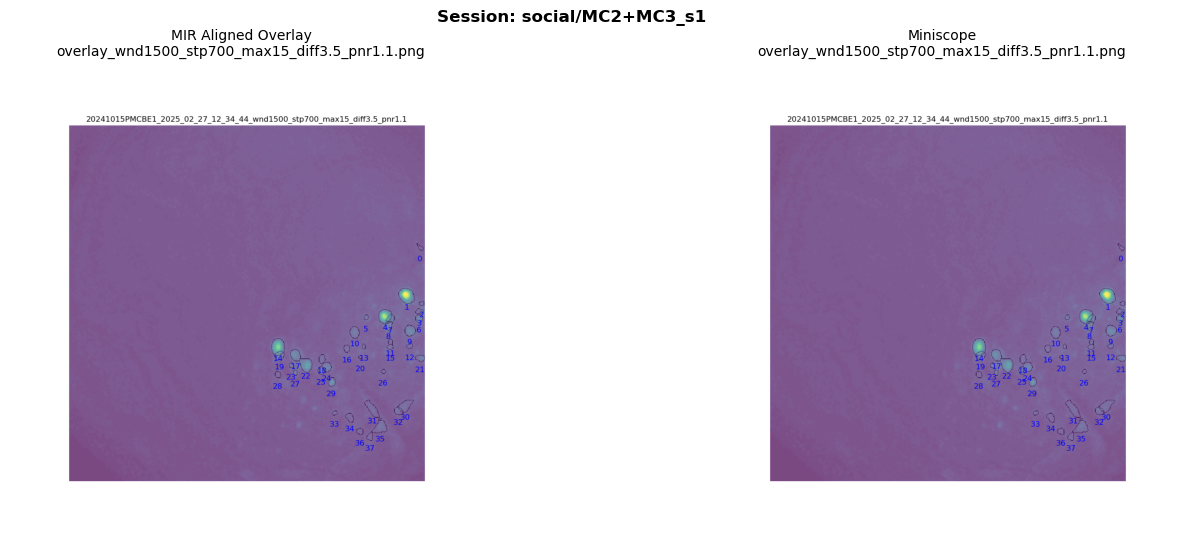

✅ social/MC2+MC3_s1


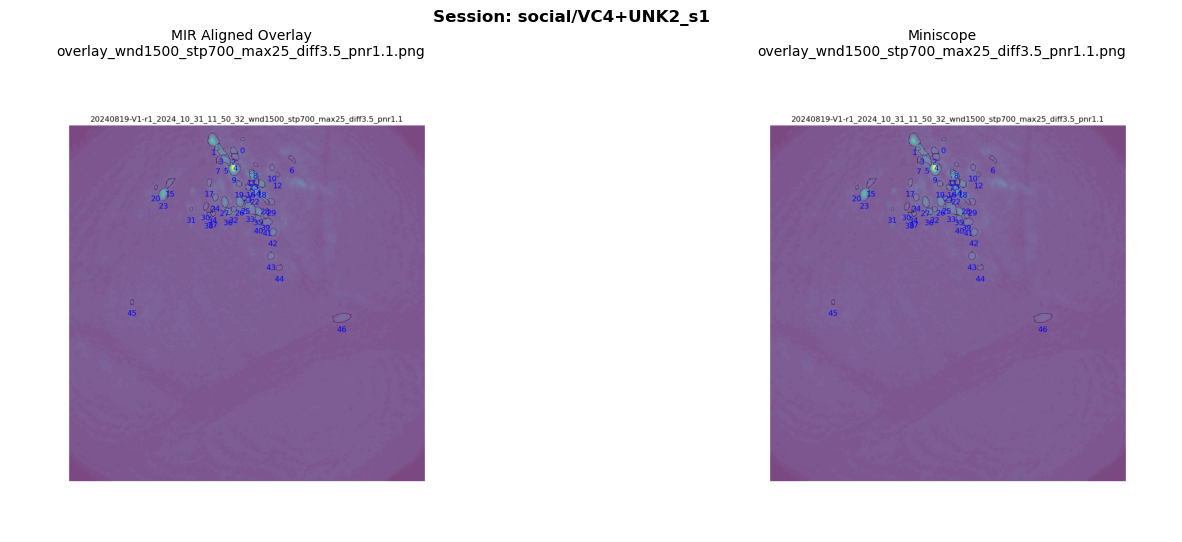

✅ social/VC4+UNK2_s1


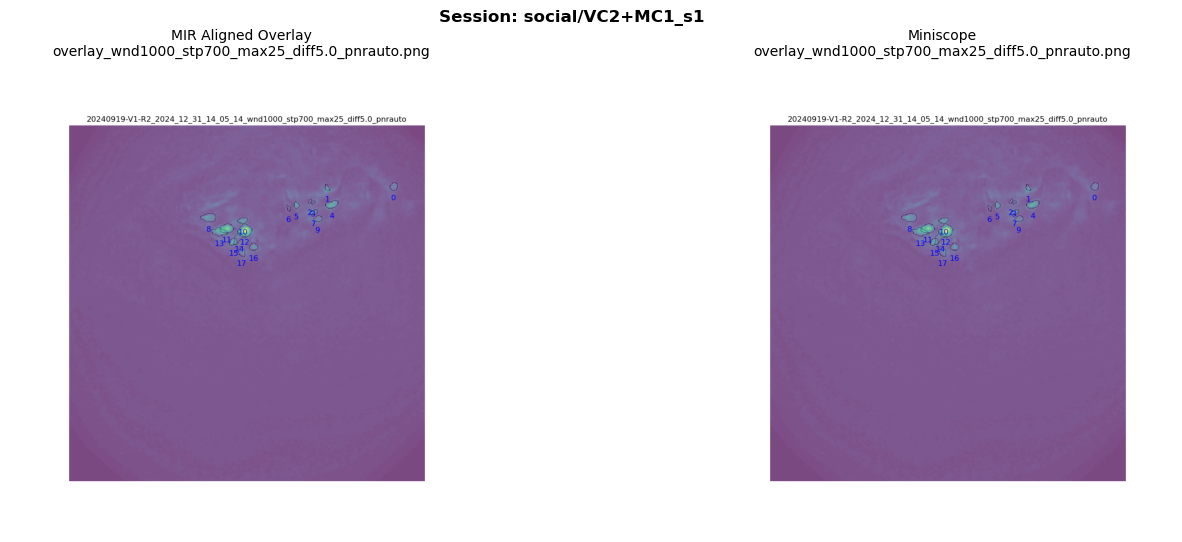

✅ social/VC2+MC1_s1
⚠️  social/MC6+UNK4_s1: No MIR overlay found


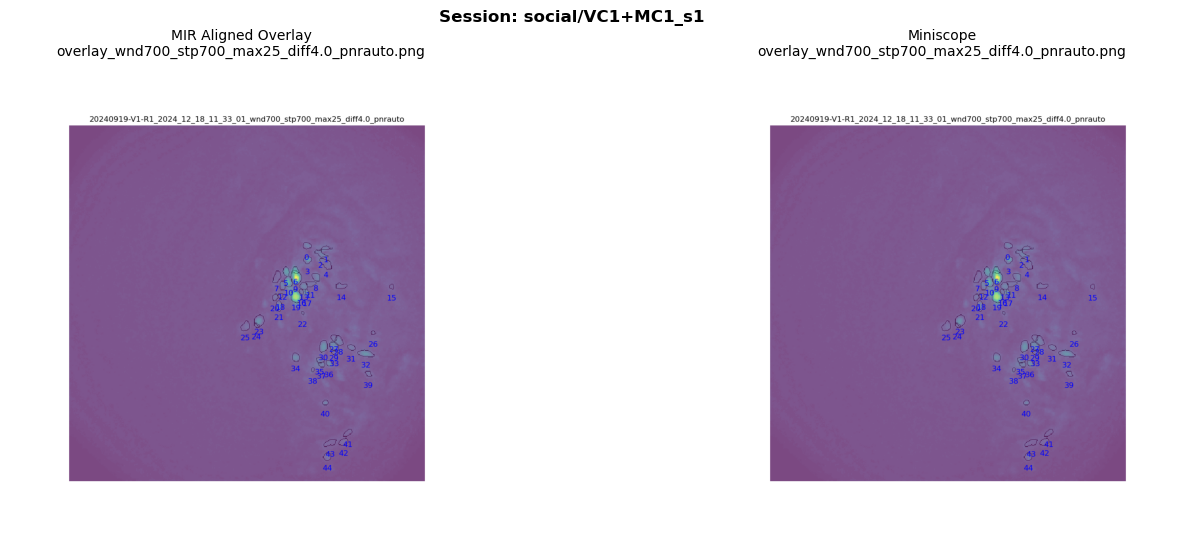

✅ social/VC1+MC1_s1


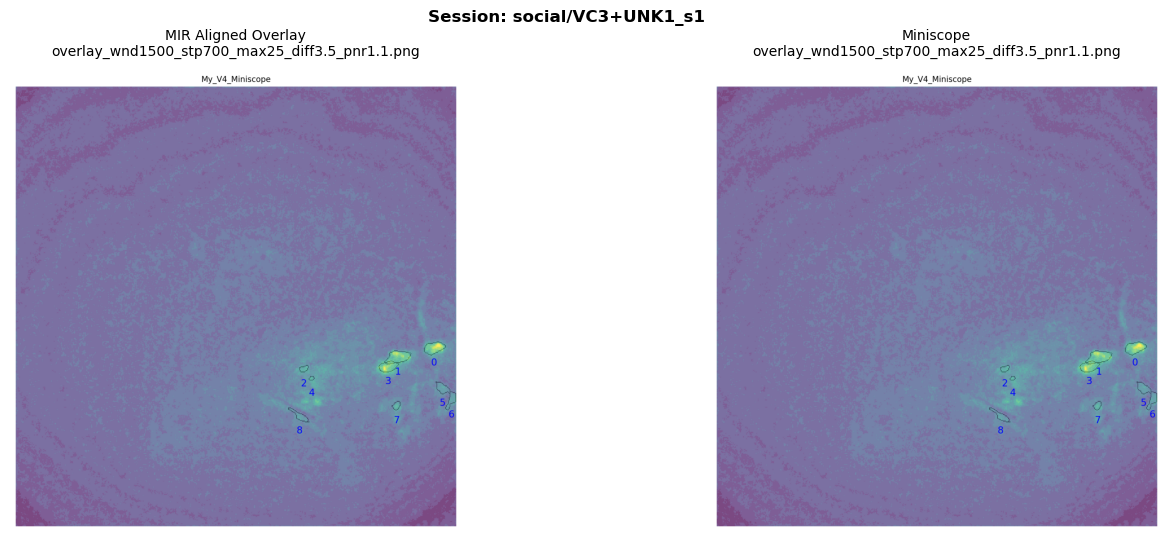

✅ social/VC3+UNK1_s1
⚠️  social/VC4+UNK1_s2: No miniscope image found


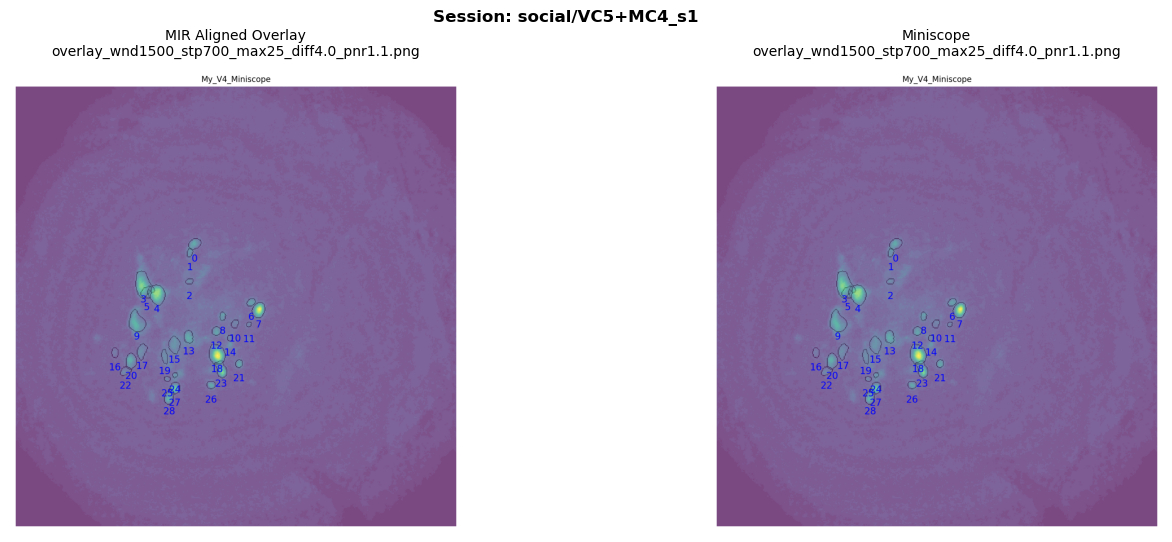

✅ social/VC5+MC4_s1


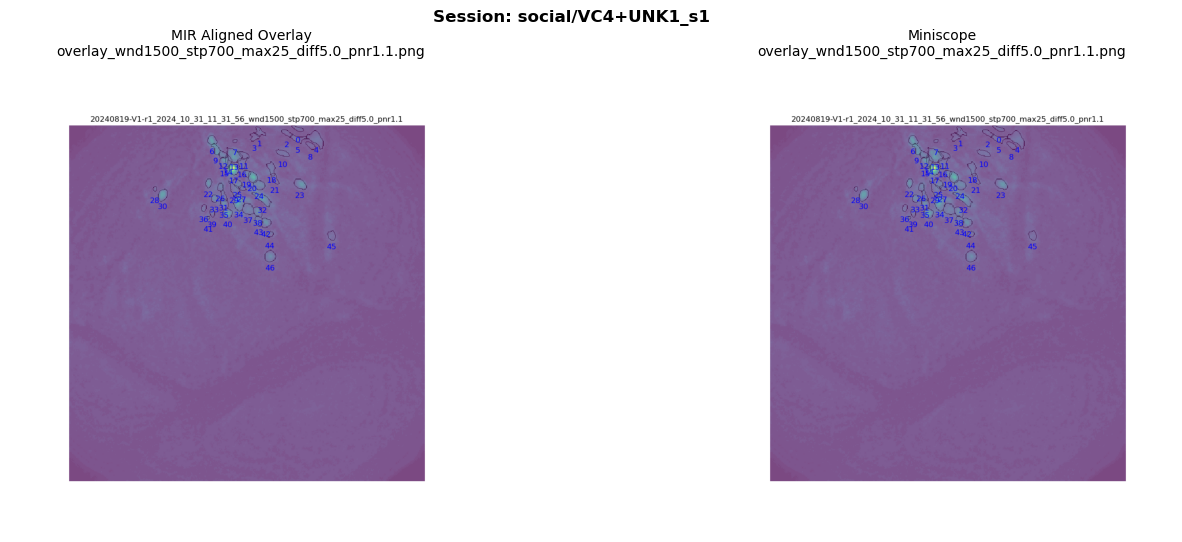

✅ social/VC4+UNK1_s1


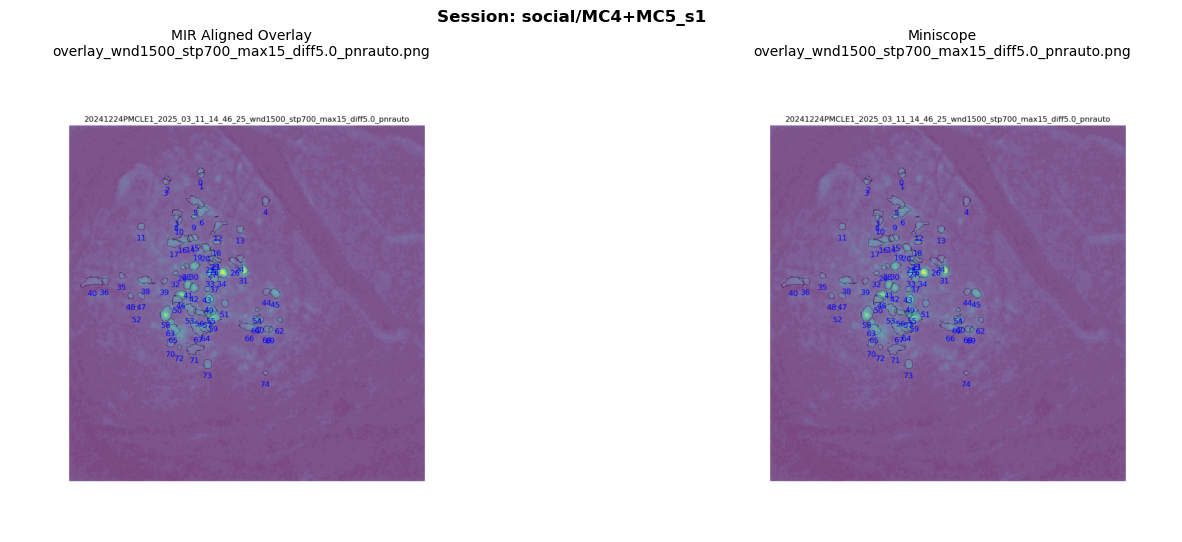

✅ social/MC4+MC5_s1


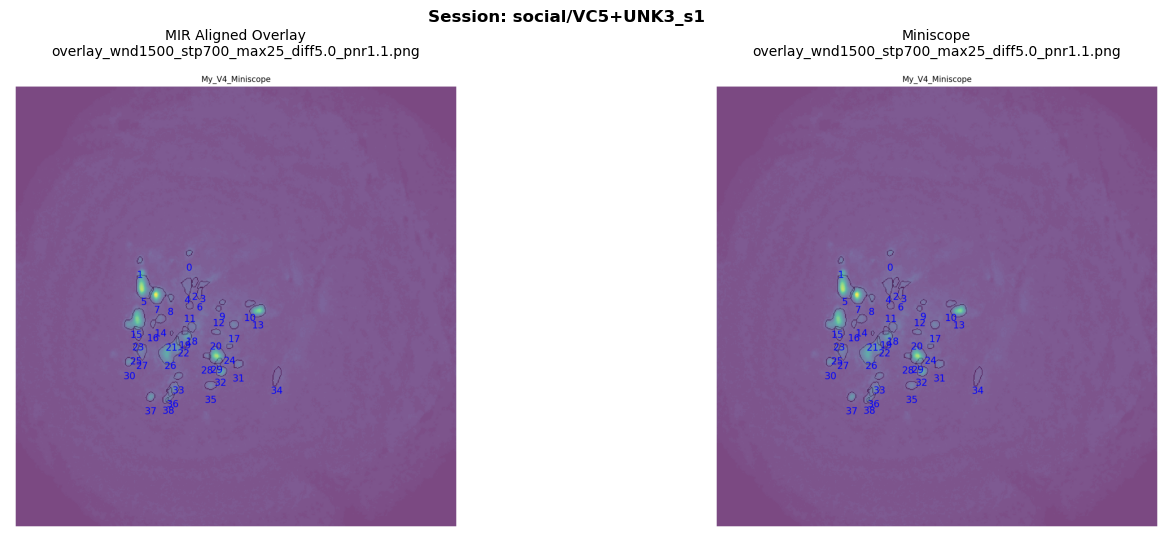

✅ social/VC5+UNK3_s1


In [10]:
import os
import glob
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

def visual_qc_exported_sessions(export_root, max_sessions=None):
    """
    Visual quality check for exported sessions.
    Shows side-by-side comparison of:
      - MIR_Aligned overlay (left)
      - My_V4_Miniscope image (right)
    
    Parameters:
    -----------
    export_root : str
        Path to export directory (e.g., '/data/.../oct3v1_social_mini')
    max_sessions : int, optional
        Maximum number of sessions to display (default: all)
    
    Returns:
    --------
    List of dicts with session info for further inspection
    """
    
    # Find all session directories
    session_dirs = []
    for root, dirs, files in os.walk(export_root):
        # Look for sessions that have both MIR_Aligned and My_V4_Miniscope
        if "MIR_Aligned" in dirs and "My_V4_Miniscope" in dirs:
            session_dirs.append(root)
    
    if not session_dirs:
        print("No sessions found with both MIR_Aligned and My_V4_Miniscope folders!")
        return []
    
    print(f"Found {len(session_dirs)} sessions to check")
    
    if max_sessions:
        session_dirs = session_dirs[:max_sessions]
    
    results = []
    
    for session_dir in session_dirs:
        session_name = os.path.relpath(session_dir, export_root)
        
        # Find MIR overlay
        mir_dir = os.path.join(session_dir, "MIR_Aligned")
        mir_pngs = glob.glob(os.path.join(mir_dir, "overlay*.png"))
        
        # Find miniscope image
        mini_dir = os.path.join(session_dir, "My_V4_Miniscope")
        mini_pngs = glob.glob(os.path.join(mini_dir, "*.png"))
        
        if not mir_pngs:
            print(f"⚠️  {session_name}: No MIR overlay found")
            continue
        
        if not mini_pngs:
            print(f"⚠️  {session_name}: No miniscope image found")
            continue
        
        # Load images
        mir_img = Image.open(mir_pngs[0])
        mini_img = Image.open(mini_pngs[0])
        
        # Create figure
        fig = plt.figure(figsize=(16, 6))
        gs = GridSpec(1, 2, figure=fig, wspace=0.3)
        
        # MIR overlay (left)
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.imshow(mir_img)
        ax1.set_title(f"MIR Aligned Overlay\n{os.path.basename(mir_pngs[0])}", 
                     fontsize=10, pad=10)
        ax1.axis('off')
        
        # Miniscope (right)
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.imshow(mini_img)
        ax2.set_title(f"Miniscope\n{os.path.basename(mini_pngs[0])}", 
                     fontsize=10, pad=10)
        ax2.axis('off')
        
        # Overall title
        fig.suptitle(f"Session: {session_name}", fontsize=12, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        plt.show()
        
        # Store info for potential aliasing check
        results.append({
            "session": session_name,
            "session_dir": session_dir,
            "mir_overlay": mir_pngs[0],
            "mini_image": mini_pngs[0],
        })
        
        print(f"✅ {session_name}")
    
    return results


# Usage example:
results = visual_qc_exported_sessions("/data/big_rim/sorted_mir_dataset/oct3v1_social_mini")
# 
# # Or check just first 5 sessions:
# results = visual_qc_exported_sessions("/data/big_rim/sorted_mir_dataset/oct3v1_social_mini", max_sessions=5)
#
# # Results contains session info if you want to build an alias map:
# for r in results:
#     print(f"{r['session']}: {r['mir_overlay']}")